In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


## 1. Baseline Setup

In [2]:
model1 = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:02<00:00, 87.2MB/s]


In [3]:
print(model1.fc)

num_classes = 10
model1.fc = nn.Linear(model1.fc.in_features, num_classes)

Linear(in_features=2048, out_features=1000, bias=True)


In [4]:
for param in model1.parameters():
    param.requires_grad = False

for param in model1.fc.parameters():
    param.requires_grad = True

model = model1.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr = 1e-3)
loss_fn = nn.CrossEntropyLoss()

In [5]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
val_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [15:40<00:00, 181kB/s]


In [6]:
def evaluate(loader, model, loss_fn):

    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_fn(out, y)
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

    return loss_sum / total, correct / total

In [ ]:
epochs = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.eval()
    model.fc.train()
    correct, total, loss_sum = 0, 0, 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    train_loss, train_acc = loss_sum / total, correct / total
    val_loss, val_acc = evaluate(val_loader, model, loss_fn)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 1/5 | train_loss=0.2943 train_acc=0.9253 | val_loss=0.1814 val_acc=0.9443
Epoch 2/5 | train_loss=0.1471 train_acc=0.9533 | val_loss=0.1634 val_acc=0.9480
Epoch 3/5 | train_loss=0.1220 train_acc=0.9608 | val_loss=0.1547 val_acc=0.9509
Epoch 4/5 | train_loss=0.1071 train_acc=0.9655 | val_loss=0.1569 val_acc=0.9489
Epoch 5/5 | train_loss=0.0961 train_acc=0.9690 | val_loss=0.1518 val_acc=0.9507


In [ ]:
import json

with open("baseline_history.json", "w") as f:
    json.dump(history, f, indent=2)

torch.save(model1.state_dict(), "resnet152_baseline_head.pth")

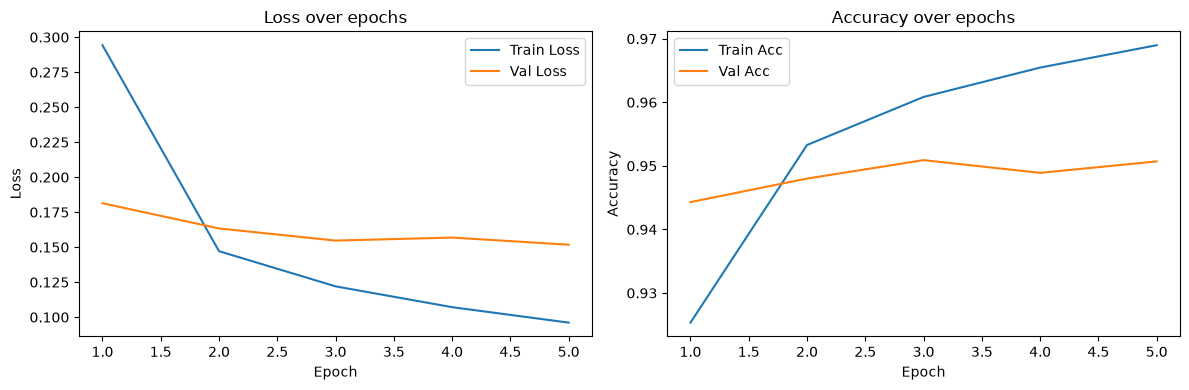

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train Loss")
axes[0].plot(epochs, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss over epochs")

axes[1].plot(epochs, history["train_acc"], label="Train Acc")
axes[1].plot(epochs, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Accuracy over epochs")

plt.tight_layout()
plt.savefig("baseline_curves.png", dpi=150)
plt.show()

## 2. Residual Connections

In [7]:
import copy
import random
import types
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


def forward_no_skip(self, x):

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    out = self.relu(out)
    return out

In [8]:
def make_section2_model(remove_skips=False):

    torch.manual_seed(SEED)

    model = models.resnet152(
        weights=models.ResNet152_Weights.IMAGENET1K_V2
    )

    model.fc = nn.Linear(model.fc.in_features, 10)

    for p in model.parameters():
        p.requires_grad = False

    for name, p in model.named_parameters():
        if "layer2" in name or "layer3" in name:
            p.requires_grad = True

    for p in model.fc.parameters():
        p.requires_grad = True

    if remove_skips:
        selected_blocks = [model.layer2[0], model.layer3[0]]

        for block in selected_blocks:
            block.forward = types.MethodType(forward_no_skip, block)

    return model.to(device)


def set_frozen_batchnorm_to_eval(model):

    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            if not any(p.requires_grad for p in module.parameters()):
                module.eval()


def evaluate_section2(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples += x.size(0)

    return total_loss / total_examples, total_correct / total_examples


def make_train_loader():

    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        train_set,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        generator=generator
    )

In [9]:
def train_section2_model(model, epochs=5, lr=1e-4):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "layer2_grad_norm": [],
        "layer3_grad_norm": [],
        "fc_grad_norm": [],
    }

    tracked_parameters = {
        "layer2_grad_norm": "layer2.0.conv1.weight",
        "layer3_grad_norm": "layer3.0.conv1.weight",
        "fc_grad_norm": "fc.weight",
    }

    for epoch in range(epochs):
        model.train()

        set_frozen_batchnorm_to_eval(model)

        train_loader_section2 = make_train_loader()

        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        epoch_grad_norms = {
            "layer2_grad_norm": [],
            "layer3_grad_norm": [],
            "fc_grad_norm": [],
        }

        for x, y in train_loader_section2:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()

            named_params = dict(model.named_parameters())

            for history_key, parameter_name in tracked_parameters.items():
                grad = named_params[parameter_name].grad

                if grad is not None:
                    epoch_grad_norms[history_key].append(
                        grad.norm().item()
                    )

            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples += x.size(0)

        train_loss = total_loss / total_examples
        train_acc = total_correct / total_examples
        val_loss, val_acc = evaluate_section2(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        for key in epoch_grad_norms:
            history[key].append(np.mean(epoch_grad_norms[key]))

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"val acc: {val_acc:.4f}"
        )

        print(
            f"  Gradient norms — "
            f"layer2: {history['layer2_grad_norm'][-1]:.6f}, "
            f"layer3: {history['layer3_grad_norm'][-1]:.6f}, "
            f"fc: {history['fc_grad_norm'][-1]:.6f}"
        )

    return history

In [ ]:
model2_normal = make_section2_model(remove_skips=False)

history2_normal = train_section2_model(
    model2_normal,
    epochs=5,
    lr=1e-4
)

torch.save(
    model2_normal.state_dict(),
    "resnet152_section2_normal_residual.pth"
)

Epoch 1/5 | train loss: 0.2558 | train acc: 0.9253 | val loss: 0.0986 | val acc: 0.9690
  Gradient norms — layer2: 0.473321, layer3: 0.302219, fc: 2.290545
Epoch 2/5 | train loss: 0.0289 | train acc: 0.9909 | val loss: 0.1266 | val acc: 0.9634
  Gradient norms — layer2: 0.197065, layer3: 0.143746, fc: 0.879393
Epoch 3/5 | train loss: 0.0187 | train acc: 0.9939 | val loss: 0.1172 | val acc: 0.9673
  Gradient norms — layer2: 0.191302, layer3: 0.142146, fc: 0.719675
Epoch 4/5 | train loss: 0.0209 | train acc: 0.9926 | val loss: 0.1304 | val acc: 0.9648
  Gradient norms — layer2: 0.201175, layer3: 0.152873, fc: 0.753934
Epoch 5/5 | train loss: 0.0156 | train acc: 0.9948 | val loss: 0.1248 | val acc: 0.9680
  Gradient norms — layer2: 0.159962, layer3: 0.125578, fc: 0.589876


In [10]:
model2_noskip = make_section2_model(remove_skips=True)

history2_noskip = train_section2_model(
    model2_noskip,
    epochs=5,
    lr=1e-4
)

torch.save(
    model2_noskip.state_dict(),
    "resnet152_section2_no_skip.pth"
)

Epoch 1/5 | train loss: 0.5795 | train acc: 0.7980 | val loss: 0.2168 | val acc: 0.9267
  Gradient norms — layer2: 2.716394, layer3: 1.263915, fc: 3.273747
Epoch 2/5 | train loss: 0.1085 | train acc: 0.9633 | val loss: 0.2208 | val acc: 0.9331
  Gradient norms — layer2: 1.071375, layer3: 0.581227, fc: 1.761641
Epoch 3/5 | train loss: 0.0420 | train acc: 0.9861 | val loss: 0.2421 | val acc: 0.9336
  Gradient norms — layer2: 0.944963, layer3: 0.528240, fc: 1.200688
Epoch 4/5 | train loss: 0.0436 | train acc: 0.9853 | val loss: 0.2496 | val acc: 0.9325
  Gradient norms — layer2: 0.926230, layer3: 0.528094, fc: 1.193997
Epoch 5/5 | train loss: 0.0371 | train acc: 0.9873 | val loss: 0.2247 | val acc: 0.9399
  Gradient norms — layer2: 0.807670, layer3: 0.478295, fc: 1.018334


In [18]:
history2_normal = {
    "train_loss": [0.2558, 0.0289, 0.0187, 0.0209, 0.0156],
    "train_acc": [0.9253, 0.9909, 0.9939, 0.9926, 0.9948],
    "val_loss": [0.0986, 0.1266, 0.1172, 0.1304, 0.1248],
    "val_acc": [0.9690, 0.9634, 0.9673, 0.9648, 0.9680],
    "layer2_grad_norm": [0.473321, 0.197065, 0.191302, 0.201175, 0.159962],
    "layer3_grad_norm": [0.302219, 0.143746, 0.142146, 0.152873, 0.125578],
    "fc_grad_norm": [2.290545, 0.879393, 0.719675, 0.753934, 0.589876],
}

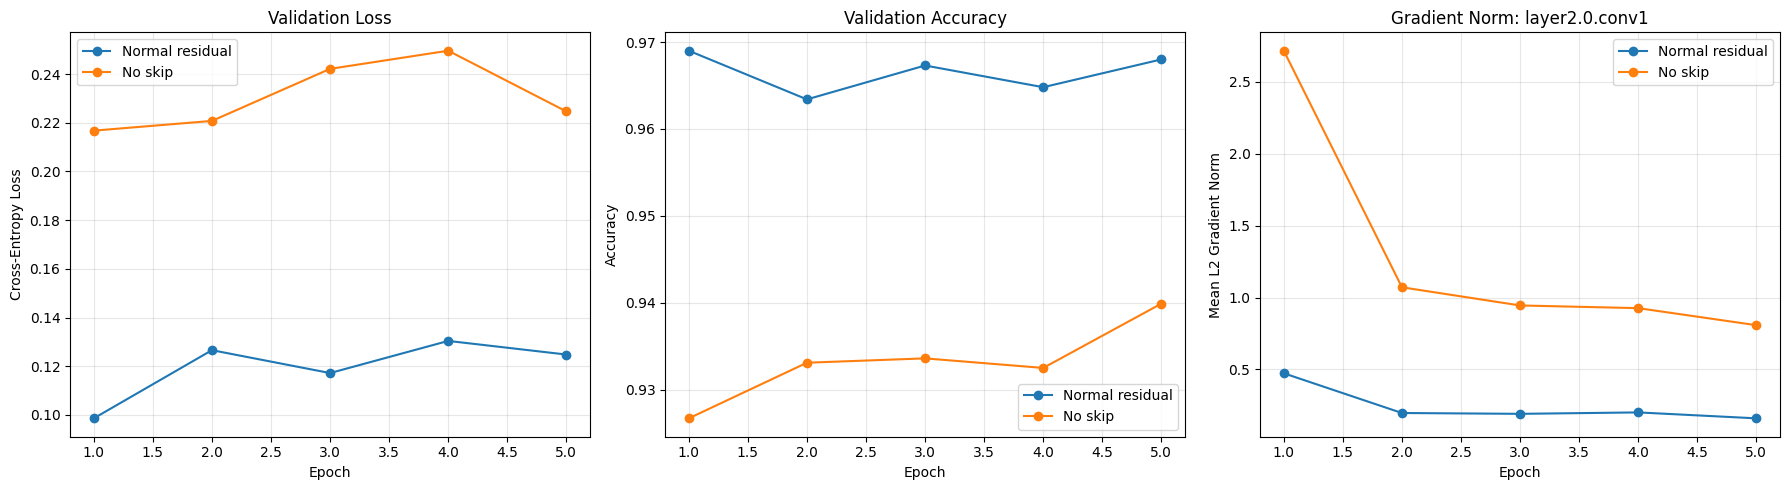

In [19]:
epochs = range(1, 6)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    epochs, history2_normal["val_loss"],
    marker="o", label="Normal residual"
)
axes[0].plot(
    epochs, history2_noskip["val_loss"],
    marker="o", label="No skip"
)
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs, history2_normal["val_acc"],
    marker="o", label="Normal residual"
)
axes[1].plot(
    epochs, history2_noskip["val_acc"],
    marker="o", label="No skip"
)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(
    epochs, history2_normal["layer2_grad_norm"],
    marker="o", label="Normal residual"
)
axes[2].plot(
    epochs, history2_noskip["layer2_grad_norm"],
    marker="o", label="No skip"
)
axes[2].set_title("Gradient Norm: layer2.0.conv1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean L2 Gradient Norm")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("section2_residual_comparison.png", dpi=150)
plt.show()

## 3. Feature Hierarchies and Representations

In [ ]:
features = {}

def get_hook(name):
    def hook(module, input, output):
        features[name] = output.detach().cpu()
    return hook

model.eval()

h1 = model1.layer1.register_forward_hook(get_hook("early"))
h2 = model1.layer3.register_forward_hook(get_hook("middle"))
h3 = model1.layer4.register_forward_hook(get_hook("late"))

In [ ]:
import numpy as np

all_features = {"early": [], "middle": [], "late": []}
all_labels = []

num_batches_to_collect = 20

with torch.no_grad():
    for i, (x, y) in enumerate(val_loader):

        if i >= num_batches_to_collect:
            break
        x = x.to(device)
        _ = model(x)

        for name in all_features:
            feat = features[name]
            feat = feat.mean(dim=[2,3])
            all_features[name].append(feat.numpy())

        all_labels.append(y.numpy())

for name in all_features:
    all_features[name] = np.concatenate(all_features[name], axis = 0)

all_labels = np.concatenate(all_labels, axis=0)

In [ ]:
h1.remove()
h2.remove()
h3.remove()

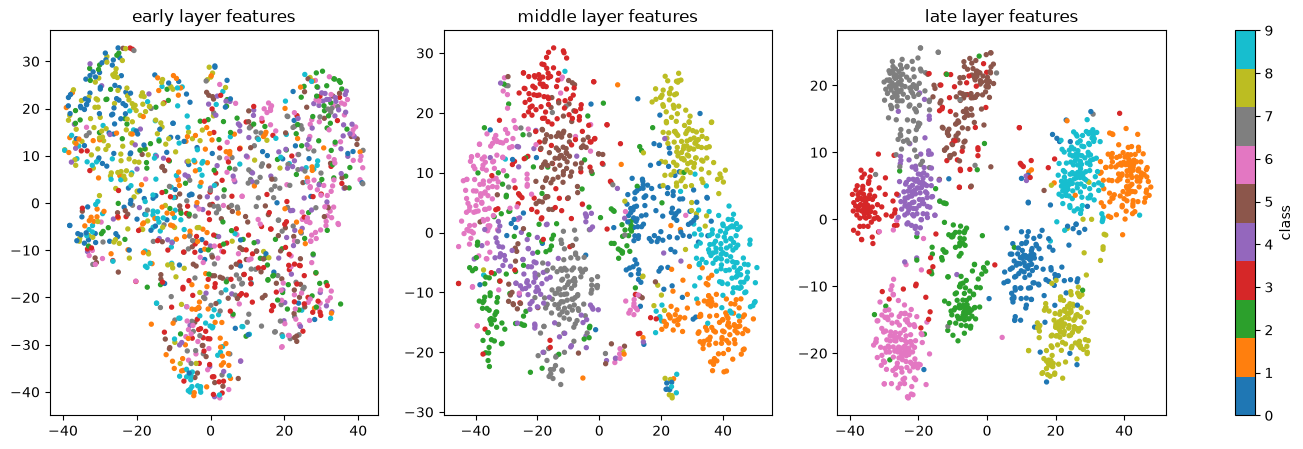

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ["early", "middle", "late"]):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(all_features[name])

    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=all_labels, cmap="tab10", s=8)
    ax.set_title(f"{name} layer features")

plt.colorbar(scatter, ax=axes, label="class")
plt.savefig("feature_tsne.png", dpi=150)
plt.show()

## 4. Transfer Learning and Generalization

In [ ]:
def build_model(pretrained, trainable_layers):

    weights = models.ResNet152_Weights.IMAGENET1K_V2 if pretrained else None
    m = models.resnet152(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)

    for param in m.parameters():
        param.requires_grad = False

    for param in m.fc.parameters():
        param.requires_grad = True

    if trainable_layers == 'final_block':
        for param in m.layer4.parameters():
            param.requires_grad = True
    elif trainable_layers == 'full':
        for param in m.parameters():
            param.requires_grad = True

    return m.to(device)


def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    def evaluate(loader):
        model.eval()
        correct, total, loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_sum += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += x.size(0)
        return loss_sum / total, correct / total

    for epoch in range(epochs):
        model.train()
        correct, total, loss_sum = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        train_loss, train_acc = loss_sum / total, correct / total
        val_loss, val_acc = evaluate(val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    return history

In [ ]:
# pretrained, final block trainable
model_a = build_model(pretrained=True, trainable_layers='final_block')
history_a = train_model(model_a, train_loader, val_loader, epochs=5, lr=1e-3)
torch.save(model_a.state_dict(), "model_a_pretrained_finalblock.pth")

Epoch 1/5 | train_loss=0.3815 train_acc=0.8728 | val_loss=0.2791 val_acc=0.9044
Epoch 2/5 | train_loss=0.1659 train_acc=0.9438 | val_loss=0.2740 val_acc=0.9103
Epoch 3/5 | train_loss=0.0834 train_acc=0.9710 | val_loss=0.2628 val_acc=0.9189
Epoch 4/5 | train_loss=0.0538 train_acc=0.9811 | val_loss=0.2672 val_acc=0.9230
Epoch 5/5 | train_loss=0.0358 train_acc=0.9882 | val_loss=0.3024 val_acc=0.9213


In [ ]:
# pretrained, full backbone trainable
model_b = build_model(pretrained=True, trainable_layers='full')
history_b = train_model(model_b, train_loader, val_loader, epochs=5, lr=1e-4)
torch.save(model_b.state_dict(), "model_b_pretrained_full.pth")

Epoch 1/5 | train_loss=0.2413 train_acc=0.9268 | val_loss=0.1005 val_acc=0.9679
Epoch 2/5 | train_loss=0.0520 train_acc=0.9833 | val_loss=0.0887 val_acc=0.9731
Epoch 3/5 | train_loss=0.0345 train_acc=0.9892 | val_loss=0.1084 val_acc=0.9672
Epoch 4/5 | train_loss=0.0314 train_acc=0.9898 | val_loss=0.0923 val_acc=0.9723
Epoch 5/5 | train_loss=0.0219 train_acc=0.9928 | val_loss=0.1113 val_acc=0.9695


In [ ]:
# random init, final layer trainable
model_c = build_model(pretrained=False, trainable_layers='final_block')
history_c = train_model(model_c, train_loader, val_loader, epochs=5, lr=1e-4)
torch.save(model_c.state_dict(), "model_c_pretrained_full.pth")

Epoch 1/5 | train_loss=2.0064 train_acc=0.2542 | val_loss=2.0149 val_acc=0.2839
Epoch 2/5 | train_loss=1.8022 train_acc=0.3359 | val_loss=1.7895 val_acc=0.3628
Epoch 3/5 | train_loss=1.7186 train_acc=0.3733 | val_loss=1.7028 val_acc=0.3765
Epoch 4/5 | train_loss=1.6657 train_acc=0.3945 | val_loss=1.6803 val_acc=0.3994
Epoch 5/5 | train_loss=1.6287 train_acc=0.4079 | val_loss=1.6247 val_acc=0.4120


In [ ]:
# random init, full backbone trainable
model_d = build_model(pretrained=False, trainable_layers='full')
history_d = train_model(model_d, train_loader, val_loader, epochs=5, lr=1e-4)
torch.save(model_d.state_dict(), "model_d_random_full.pth")

Epoch 1/5 | train_loss=1.8444 train_acc=0.3210 | val_loss=1.6314 val_acc=0.4088
Epoch 2/5 | train_loss=1.4589 train_acc=0.4689 | val_loss=1.3925 val_acc=0.5061
Epoch 3/5 | train_loss=1.2486 train_acc=0.5489 | val_loss=1.1561 val_acc=0.5844
Epoch 4/5 | train_loss=1.0698 train_acc=0.6190 | val_loss=1.0319 val_acc=0.6315
Epoch 5/5 | train_loss=0.8983 train_acc=0.6828 | val_loss=0.8963 val_acc=0.6809


In [ ]:
history_a = {
    "train_loss": [0.3815, 0.1659, 0.0834, 0.0538, 0.0358],
    "train_acc": [0.8728, 0.9438, 0.9710, 0.9811, 0.9882],
    "val_loss": [0.2791, 0.2740, 0.2628, 0.2672, 0.3024],
    "val_acc": [0.9044, 0.9103, 0.9189, 0.9230, 0.9213],
}

history_b = {
    "train_loss": [0.2413, 0.0520, 0.0345, 0.0314, 0.0219],
    "train_acc": [0.9268, 0.9833, 0.9892, 0.9898, 0.9928],
    "val_loss": [0.1005, 0.0887, 0.1084, 0.0923, 0.1113],
    "val_acc": [0.9679, 0.9731, 0.9672, 0.9723, 0.9695],
}

history_c = {
    "train_loss": [2.0064, 1.8022, 1.7186, 1.6657, 1.6287],
    "train_acc": [0.2542, 0.3359, 0.3733, 0.3945, 0.4079],
    "val_loss": [2.0149, 1.7895, 1.7028, 1.6803, 1.6247],
    "val_acc": [0.2839, 0.3628, 0.3765, 0.3994, 0.4120],
}

history_d = {
    "train_loss": [1.8444, 1.4589, 1.2486, 1.0698, 0.8983],
    "train_acc": [0.3210, 0.4689, 0.5489, 0.6190, 0.6828],
    "val_loss": [1.6314, 1.3925, 1.1561, 1.0319, 0.8963],
    "val_acc": [0.4088, 0.5061, 0.5844, 0.6315, 0.6809],
}

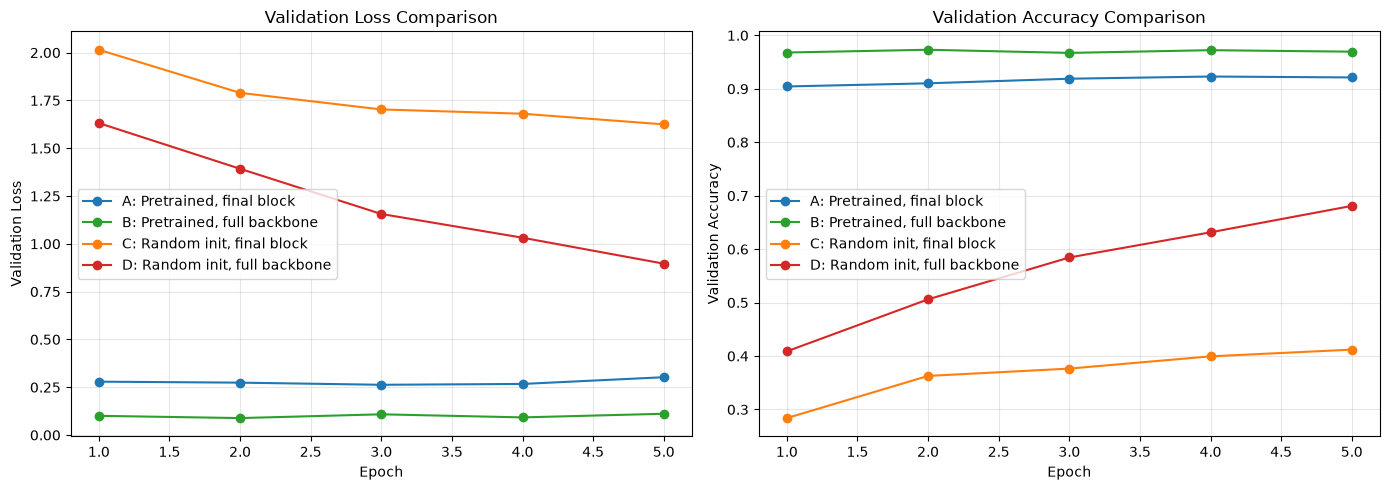

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_dict = {
    "A: Pretrained, final block": history_a,
    "B: Pretrained, full backbone": history_b,
    "C: Random init, final block": history_c,
    "D: Random init, full backbone": history_d,
}

colors = {
    "A: Pretrained, final block": "tab:blue",
    "B: Pretrained, full backbone": "tab:green",
    "C: Random init, final block": "tab:orange",
    "D: Random init, full backbone": "tab:red",
}

for name, hist in models_dict.items():
    epochs = range(1, len(hist["val_loss"]) + 1)
    axes[0].plot(
        epochs, hist["val_loss"], marker="o", label=name, color=colors[name]
    )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Validation Loss Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, hist in models_dict.items():
    epochs = range(1, len(hist["val_acc"]) + 1)
    axes[1].plot(
        epochs, hist["val_acc"], marker="o", label=name, color=colors[name]
    )

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy Comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task4_comparison.png", dpi=150)
plt.show()

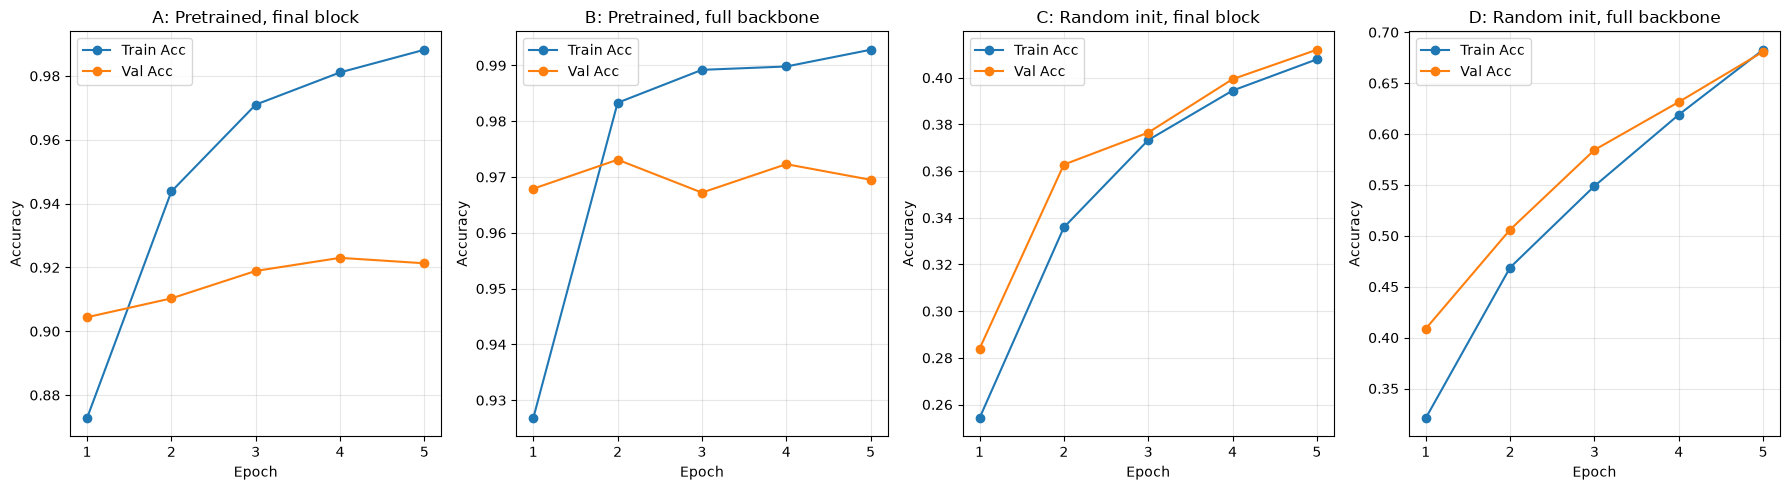

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (name, hist) in zip(axes, models_dict.items()):
    epochs = range(1, len(hist["train_acc"]) + 1)
    ax.plot(epochs, hist["train_acc"], marker='o', label="Train Acc")
    ax.plot(epochs, hist["val_acc"], marker='o', label="Val Acc")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task4_train_val_gap.png", dpi=150)
plt.show()

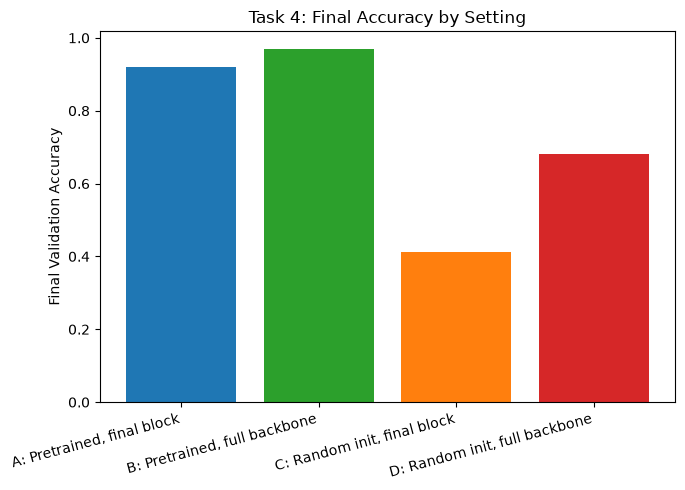

In [ ]:
final_accs = {name: hist["val_acc"][-1] for name, hist in models_dict.items()}

plt.figure(figsize=(7, 5))
plt.bar(final_accs.keys(), final_accs.values(), color=[colors[k] for k in final_accs])
plt.ylabel("Final Validation Accuracy")
plt.title("Task 4: Final Accuracy by Setting")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("task4_final_bar.png", dpi=150)
plt.show()

## 5a. t-SNE vs UMAP

c:\Users\Taha\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Taha\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Taha\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


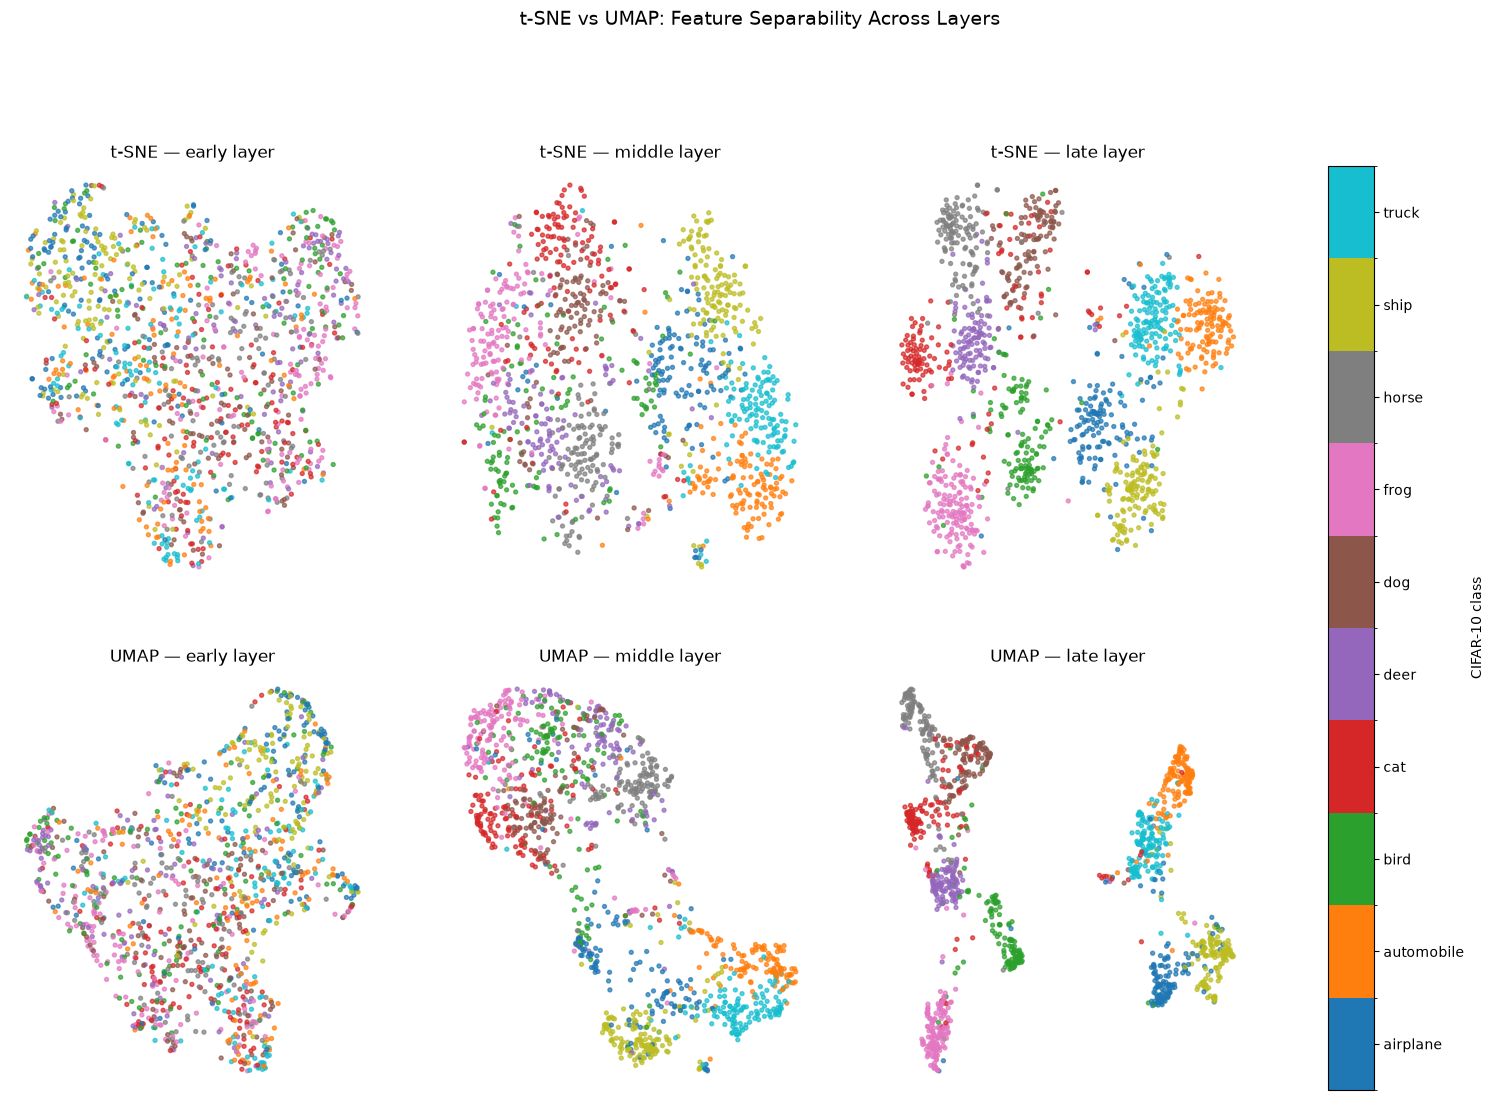

In [ ]:
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

for col, name in enumerate(["early", "middle", "late"]):
    feats = all_features[name]

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_reduced = tsne.fit_transform(feats)

    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_reduced = reducer.fit_transform(feats)

    scatter_tsne = axes[0, col].scatter(
        tsne_reduced[:, 0], tsne_reduced[:, 1],
        c=all_labels, cmap="tab10", vmin=0, vmax=9, s=8, alpha=0.7
    )
    axes[0, col].set_title(f"t-SNE — {name} layer")
    axes[0, col].axis("off")

    axes[1, col].scatter(
        umap_reduced[:, 0], umap_reduced[:, 1],
        c=all_labels, cmap="tab10", vmin=0, vmax=9, s=8, alpha=0.7
    )
    axes[1, col].set_title(f"UMAP — {name} layer")
    axes[1, col].axis("off")

import matplotlib as mpl
cmap = mpl.cm.tab10
bounds = np.arange(11)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), ticks=np.arange(10) + 0.5)
cbar.set_ticklabels(cifar10_classes)
cbar.set_label("CIFAR-10 class")

plt.suptitle("t-SNE vs UMAP: Feature Separability Across Layers", fontsize=14, y=1.01)
plt.savefig("tsne_vs_umap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5b. Class Confusion Analysis

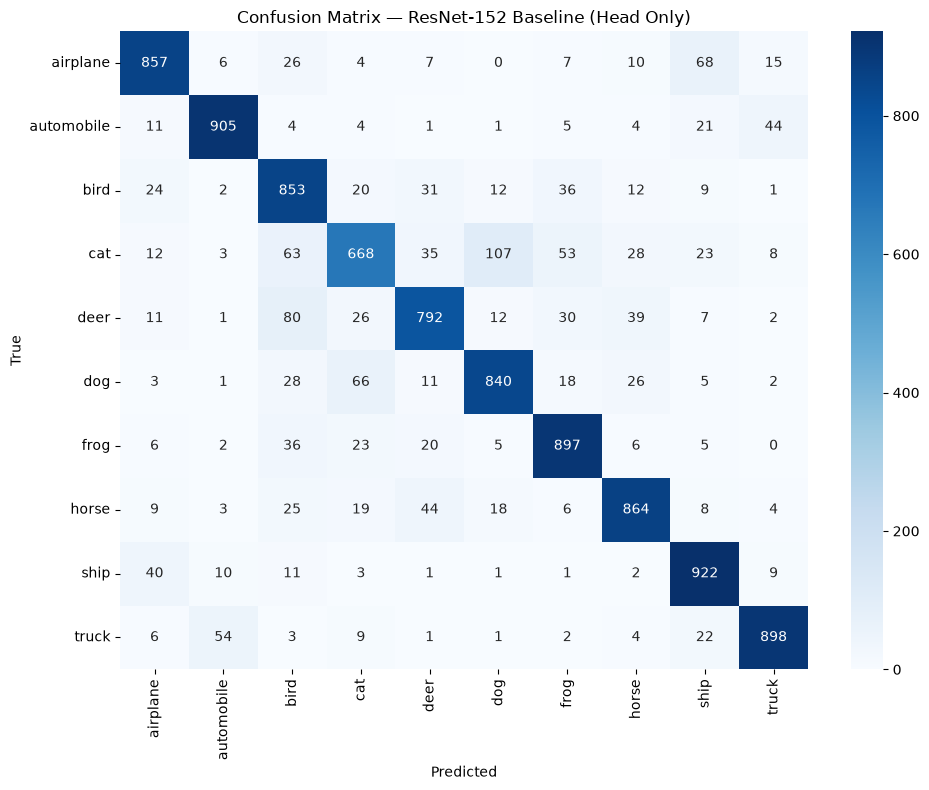


Most confused class pairs (true -> predicted, count):
  cat          -> dog         : 107
  deer         -> bird        : 80
  airplane     -> ship        : 68
  dog          -> cat         : 66
  cat          -> bird        : 63
  truck        -> automobile  : 54
  cat          -> frog        : 53
  automobile   -> truck       : 44
  horse        -> deer        : 44
  ship         -> airplane    : 40


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.load_state_dict(torch.load("resnet152_baseline_head.pth"))
model = model.to(device)
model.eval()

cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

all_preds = []
all_true  = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cifar10_classes,
            yticklabels=cifar10_classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — ResNet-152 Baseline (Head Only)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMost confused class pairs (true -> predicted, count):")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

flat_indices = np.argsort(cm_no_diag.ravel())[::-1][:10]
for idx in flat_indices:
    true_class = idx // 10
    pred_class = idx % 10
    count = cm_no_diag[true_class, pred_class]
    print(f"  {cifar10_classes[true_class]:12s} -> {cifar10_classes[pred_class]:12s}: {count}")

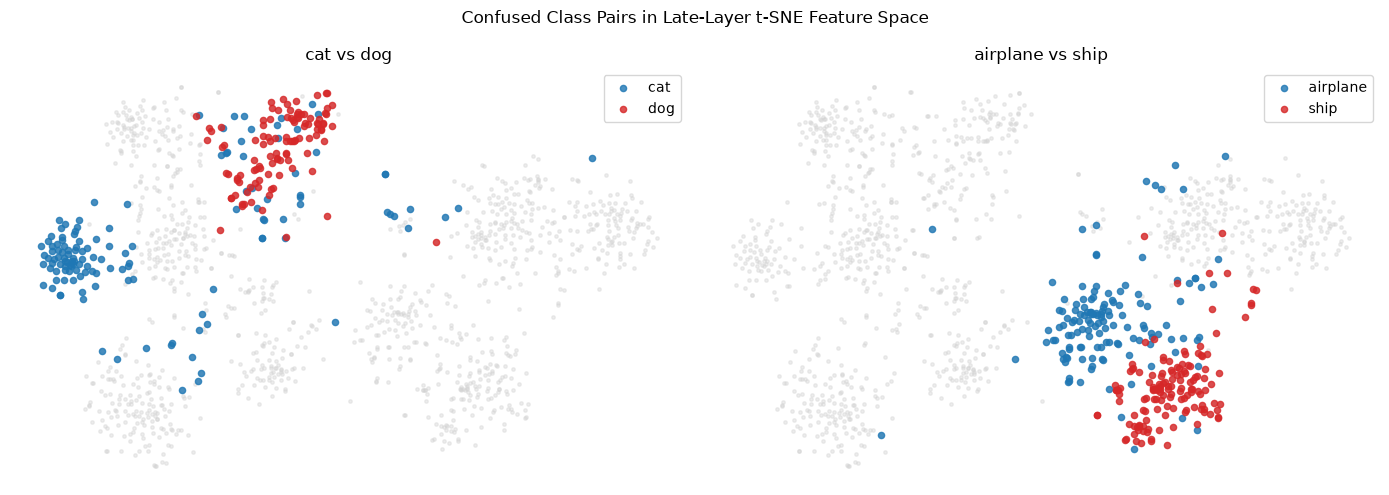

In [ ]:

late_feats = all_features["late"]
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(late_feats)


confused_pairs = [(3, 5), (0, 8)]

fig, axes = plt.subplots(1, len(confused_pairs), figsize=(14, 5))

for ax, (class_a, class_b) in zip(axes, confused_pairs):

    ax.scatter(reduced[:, 0], reduced[:, 1], c="lightgray", s=6, alpha=0.4)

    mask_a = all_labels == class_a
    ax.scatter(reduced[mask_a, 0], reduced[mask_a, 1],
               c="tab:blue", s=20, label=cifar10_classes[class_a], alpha=0.8)

    mask_b = all_labels == class_b
    ax.scatter(reduced[mask_b, 0], reduced[mask_b, 1],
               c="tab:red", s=20, label=cifar10_classes[class_b], alpha=0.8)

    ax.set_title(f"{cifar10_classes[class_a]} vs {cifar10_classes[class_b]}")
    ax.legend()
    ax.axis("off")

plt.suptitle("Confused Class Pairs in Late-Layer t-SNE Feature Space")
plt.tight_layout()
plt.savefig("confused_pairs_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## 5c. ResNet-152 vs ResNet-18

In [ ]:
from torchvision import models
import types

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet18.eval()
resnet18 = resnet18.to(device)

features_18 = {}
features_152 = {}

def get_hook(storage, name):
    def hook(module, input, output):
        storage[name] = output.detach().cpu()
    return hook

h18_early  = resnet18.layer1.register_forward_hook(get_hook(features_18, "early"))
h18_middle = resnet18.layer3.register_forward_hook(get_hook(features_18, "middle"))
h18_late   = resnet18.layer4.register_forward_hook(get_hook(features_18, "late"))

h152_early  = model.layer1.register_forward_hook(get_hook(features_152, "early"))
h152_middle = model.layer3.register_forward_hook(get_hook(features_152, "middle"))
h152_late   = model.layer4.register_forward_hook(get_hook(features_152, "late"))

num_batches = 20
all_feats_18  = {"early": [], "middle": [], "late": []}
all_feats_152 = {"early": [], "middle": [], "late": []}
labels_shared = []

with torch.no_grad():
    for i, (x, y) in enumerate(val_loader):
        if i >= num_batches:
            break
        x = x.to(device)

        resnet18(x)
        for name in all_feats_18:
            feat = features_18[name].mean(dim=[2, 3])
            all_feats_18[name].append(feat.numpy())

        model(x)
        for name in all_feats_152:
            feat = features_152[name].mean(dim=[2, 3])
            all_feats_152[name].append(feat.numpy())

        labels_shared.append(y.numpy())

for name in all_feats_18:
    all_feats_18[name]  = np.concatenate(all_feats_18[name],  axis=0)
    all_feats_152[name] = np.concatenate(all_feats_152[name], axis=0)
labels_shared = np.concatenate(labels_shared, axis=0)

for h in [h18_early, h18_middle, h18_late, h152_early, h152_middle, h152_late]:
    h.remove()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Taha/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 5.95MB/s]


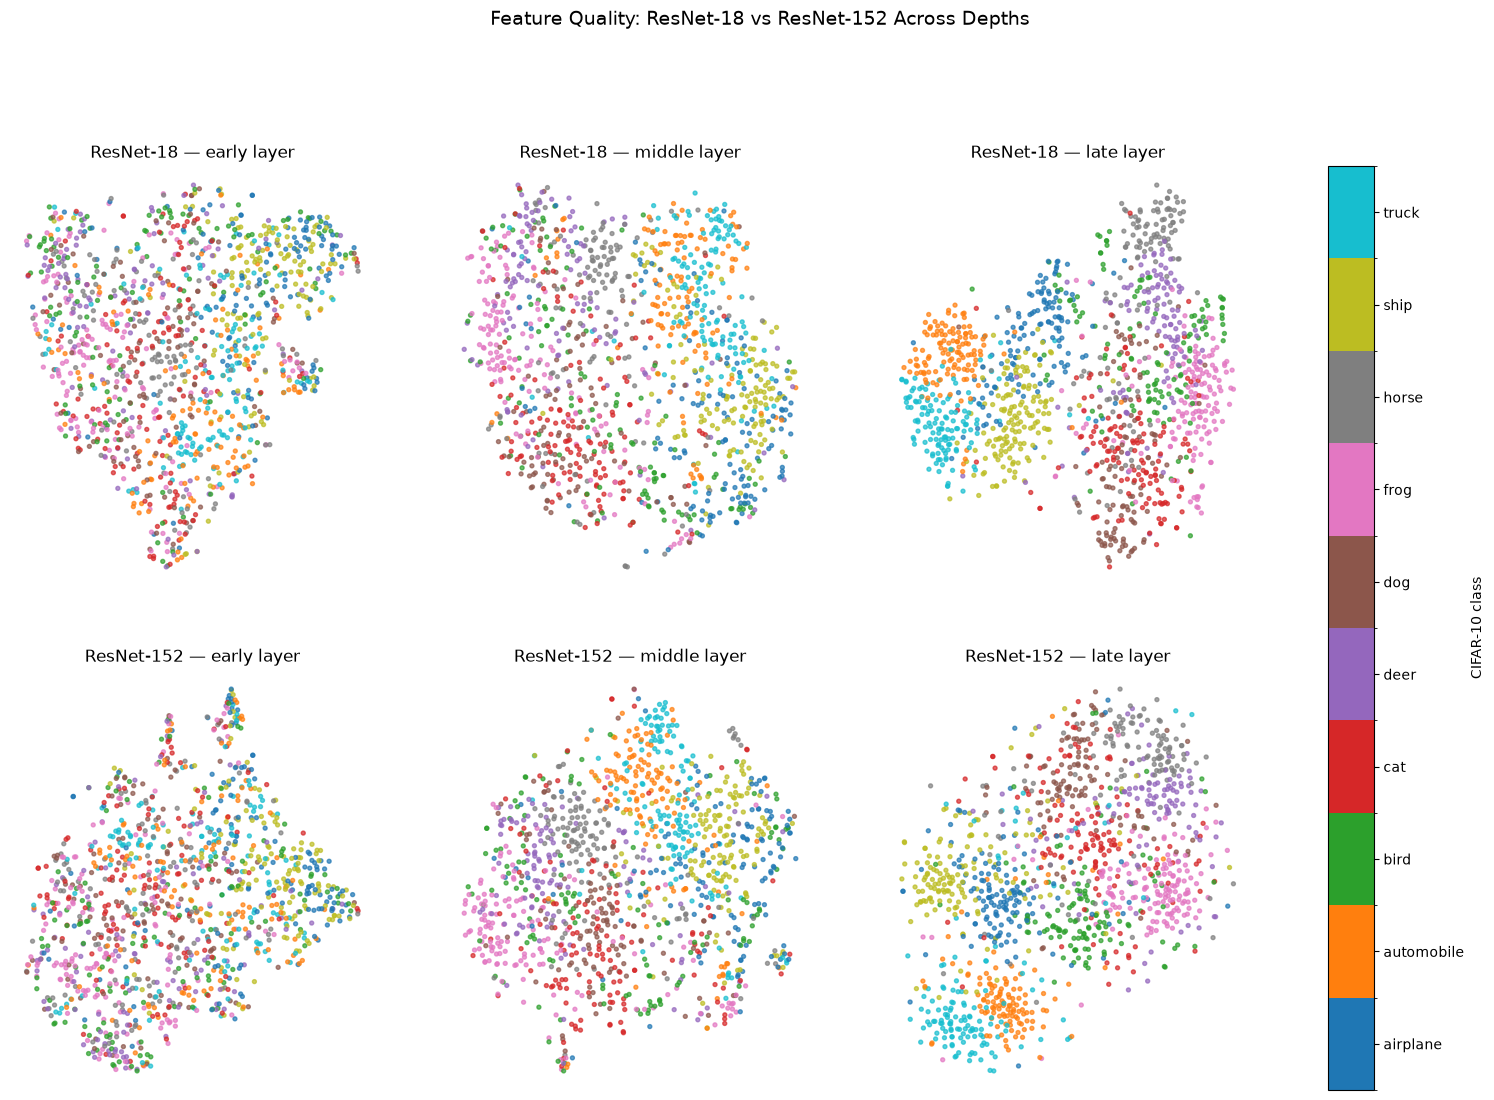

In [ ]:
import matplotlib as mpl

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
layer_names = ["early", "middle", "late"]
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

for col, name in enumerate(layer_names):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)

    reduced_18 = tsne.fit_transform(all_feats_18[name])
    axes[0, col].scatter(reduced_18[:, 0], reduced_18[:, 1],
                          c=labels_shared, cmap="tab10", vmin=0, vmax=9, s=8, alpha=0.7)
    axes[0, col].set_title(f"ResNet-18 — {name} layer")
    axes[0, col].axis("off")

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced_152 = tsne.fit_transform(all_feats_152[name])
    axes[1, col].scatter(reduced_152[:, 0], reduced_152[:, 1],
                          c=labels_shared, cmap="tab10", vmin=0, vmax=9, s=8, alpha=0.7)
    axes[1, col].set_title(f"ResNet-152 — {name} layer")
    axes[1, col].axis("off")

cmap = mpl.cm.tab10
bounds = np.arange(11)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), ticks=np.arange(10) + 0.5)
cbar.set_ticklabels(cifar10_classes)
cbar.set_label("CIFAR-10 class")

plt.suptitle("Feature Quality: ResNet-18 vs ResNet-152 Across Depths", fontsize=14, y=1.01)
plt.savefig("resnet18_vs_152_tsne.png", dpi=150, bbox_inches="tight")
plt.show()